In [2]:
import sys
import networkx as nx
import numpy as np
import pypsa
from scipy.sparse import spdiags

sys.path.append('./')
from power_system_split import utils, cascade_sim
from matplotlib import pyplot as plt

import pandas as pd
from tqdm import tqdm


# Setup

In [3]:
# Setup paths to solved PyPSA networks and results of this script
path_to_pypsa_network   = './data/sclopf_test_data/'
#save_path =  './results/cascade_results/sclopf/'

# Setup parameters
co2l = 0.5
selected_snapshot_idxs = [0] # np.random.randint(0,2920, size=1)

# Load PyPSA network and prepare matrices

In [101]:
# Load PyPSA network
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+ 'sclopf-elec_s_800_ec_lv1.0_Co2L0.0-2920SEG-0.nc') #f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')

# The following line is needed to remove the outage lines used for SCLOPF. When not removed, multiple edges 
# are added to the network graph
duplicated_lines = network.lines[network.lines.index.str[-6:]!='outage'].index
network.lines.loc[duplicated_lines + '_outage', 'num_parallel'] +=  network.lines.loc[duplicated_lines, 'num_parallel'].values
network.lines.loc[duplicated_lines + '_outage', 's_nom'] +=  network.lines.loc[duplicated_lines, 's_nom'].values
network.lines_t.p0.loc[:, duplicated_lines + '_outage'] += network.lines_t.p0.loc[:, duplicated_lines].values
network.lines_t.p1.loc[:, duplicated_lines + '_outage'] += network.lines_t.p1.loc[:, duplicated_lines].values

network.mremove('Line', duplicated_lines)
network.determine_network_topology()
network.calculate_dependent_values()

/home/jkruse/miniconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/miniconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.0-2920SEG-0.nc has buses, carriers, generators, lines, links, loads, storage_units


In [102]:

######
#TODO: remove this line if the networks contain timestamp snapshots
network.snapshots = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

network.snapshot_weightings.index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

for component in network.all_components:
    pnl = network.pnl(component)
    attrs = network.components[component]["attrs"]

    for k,default in attrs.default[attrs.varying].iteritems():
        pnl[k].index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))
######

# Select a particular subnetwork for calculations (if the pypsa network has different ones).
# For our data set, "0" indicates the Continental European AC grid. 
snet_index = 0

# Build graph for subnetwork
G = utils.build_networkx_graph(network, snet_index= snet_index)

# Get line index 
# Line index is a unique number to identify the given edge.
# It is directly extracted from pypsa
indices = nx.get_edge_attributes(G, 'line_index')

# Build incidence matrix and susceptance matrix
I_m = utils.construct_incidencematrix_from_orientation(G,return_np_array = False)
B_d = spdiags(np.array([attribs['weight'] for u,v, attribs in G.edges(data=True)]),
            0,G.number_of_edges(),G.number_of_edges()).asformat('csr')

# Get array of num_parallels and of line limits
num_parallel_list = np.array([attribs['num_parallel'] for u,v, attribs in G.edges(data=True)])
line_limit_list = np.array([attribs['s_nom'] for u,v, attribs in G.edges(data=True)])

# Calculate possible single line failure (using non-bridges)
bridges = list(nx.bridges(nx.Graph(G)))
link_indices = dict(zip(G.edges(), range(G.number_of_edges())))
bridges_indices = [link_indices[link_name] for link_name in bridges]
n_minus_1_failures = list(set(range(len(num_parallel_list))) - set(bridges_indices))

# Simulation of N-1 failures

In [117]:
cascade_results = pd.DataFrame(columns=['snapshot','snapshot_idx', 'co2l', 'epsilon',
                                        'init_failure_idx', 'init_failure_name',
                                        'num_parallel_before', 'num_parallel_after',
                                        'n_secondary_failures', 'secondary_failures_indices'])

i=0
for snapshot_idx in selected_snapshot_idxs:
    
    snapshot = network.snapshots[snapshot_idx]
    
    print(snapshot)
    initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                        e, index_list in indices.items()}
    P_0 = utils.get_effective_injections(G, initial_loading)
    
    for init_failure in tqdm(n_minus_1_failures):
        
        initial_failure = [init_failure]
        failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                    num_parallel_list, initial_failure,
                                                                    max_cascade_length=1, epsilon=0)
        cascade_results.loc[i,'snapshot'] = snapshot
        cascade_results.loc[i,'snapshot_idx'] = snapshot_idx
        cascade_results.loc[i,'co2l'] = co2l
        cascade_results.loc[i,'epsilon'] = 0.01
        cascade_results.loc[i,'init_failure_idx'] = init_failure
        cascade_results.loc[i,'init_failure_name'] = utils.transform_cascade_results(G, [init_failure])[0]
        cascade_results.loc[i,'num_parallel_before'] = num_parallel_list[init_failure]
        cascade_results.loc[i,'num_parallel_after'] = cascade_sim.calc_num_parallel_after_failure(num_parallel_list[init_failure])
        cascade_results.loc[i,'n_secondary_failures'] = len(failing_links)-1
        cascade_results.loc[i,'secondary_failures_indices'] = failing_links[1:]
        i+=1

cascade_results

  2%|▏         | 21/932 [00:00<00:04, 205.41it/s]

2013-01-01 00:00:00


100%|██████████| 932/932 [00:02<00:00, 333.69it/s]


,snapshot,snapshot_idx,co2l,epsilon,init_failure_idx,init_failure_name,num_parallel_before,num_parallel_after,n_secondary_failures,secondary_failures_indices
0,2013-01-01 00:00:00,0,0.5,0.01,0,"(AL1 0, GR1 0)",1.000000,0,8,"[59, 152, 199, 226, 236, 246, 358, 632]"
1,2013-01-01 00:00:00,0,0.5,0.01,1,"(AL1 0, ME1 0)",1.289474,0.289474,7,"[59, 152, 199, 226, 236, 246, 632]"
2,2013-01-01 00:00:00,0,0.5,0.01,2,"(AL1 0, RS1 4)",1.000000,0,3,"[51, 783, 797]"
3,2013-01-01 00:00:00,0,0.5,0.01,3,"(AL1 0, RS1 6)",0.289474,0,2,"[51, 783]"
4,2013-01-01 00:00:00,0,0.5,0.01,4,"(GR1 0, GR1 1)",4.000000,3.000000,0,[]
...,...,...,...,...,...,...,...,...,...,...
927,2013-01-01 00:00:00,0,0.5,0.01,957,"(RS1 0, RS1 9)",0.289474,0,8,"[59, 152, 199, 226, 236, 246, 632, 802]"
928,2013-01-01 00:00:00,0,0.5,0.01,958,"(RO1 10, RO1 5)",0.289474,0,0,[]
929,2013-01-01 00:00:00,0,0.5,0.01,959,"(RO1 5, RO1 9)",0.289474,0,0,[]
930,2013-01-01 00:00:00,0,0.5,0.01,960,"(RO1 11, RO1 12)",0.289474,0,0,[]


In [123]:
post_flows_pypsa = pd.read_csv('./data/sclopf_test_data/lpf_contingency.csv', index_col=[0])
post_flows_pypsa.loc[duplicated_lines + '_outage'] += post_flows_pypsa.loc[duplicated_lines].values
post_flows_pypsa = post_flows_pypsa[~post_flows_pypsa.index.isin(duplicated_lines)]
post_flows_pypsa

,base,"('Line', '1357_outage')","('Line', '1356_outage')","('Line', '1355_outage')","('Line', '1354_outage')"
1_outage,-767.595456,-767.595461,-767.595457,-767.595457,-767.595456
2_outage,177.077452,177.077462,177.077455,177.077454,177.077453
4_outage,242.727569,242.727565,242.727568,242.727568,242.727569
5_outage,113.545384,113.545383,113.545384,113.545384,113.545384
6_outage,448.901989,448.901967,448.902009,448.901999,448.902005
...,...,...,...,...,...
1353_outage,-0.038868,-0.048267,-0.040244,-0.037895,-0.041064
1354_outage,-0.013618,-0.015663,-0.013225,-0.013175,0.000000
1355_outage,0.002764,0.020516,0.002553,0.000000,0.001932
1356_outage,-0.117440,-0.120643,-0.110106,-0.117326,-0.117042


# Evaluation of one initial failure event

In [183]:
init_failure_pypsa_idx = '1357_outage'

res = cascade_results[cascade_results.init_failure_name==(network.lines.loc[init_failure_pypsa_idx].bus1, network.lines.loc[init_failure_pypsa_idx].bus0)]
if res.empty:
    res = cascade_results[cascade_results.init_failure_name==(network.lines.loc[init_failure_pypsa_idx].bus0, network.lines.loc[init_failure_pypsa_idx].bus1)]
res

,snapshot,snapshot_idx,co2l,epsilon,init_failure_idx,init_failure_name,num_parallel_before,num_parallel_after,n_secondary_failures,secondary_failures_indices
304,2013-01-01 00:00:00,0,0.5,0.01,308,"(SK1 6, SK1 4)",0.289474,0,0,[]


In [150]:
init_line_info = network.lines.loc[[init_failure_pypsa_idx]]    
init_line_info

,bus0,bus1,num_parallel,length,type,s_nom,capital_cost,x,r,b,...,s_nom_max,s_max_pu,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
name,,,,,,,,,,,,,,,,,,,,,
1357_outage,SK1 4,SK1 6,0.289474,61.713253,Al/St 240/40 4-bundle 380.0,491.556019,2545.204981,52.445044,6.395737,0.000077,...,inf,1.0,1.0,-inf,inf,0,0.000363,0.000044,0.0,11.183653


In [146]:
# Choose result 
result_idx = 304

# Pre-failure flow
snapshot = cascade_results.iloc[result_idx].snapshot
initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                   e, index_list in indices.items()}
P_0 = utils.get_effective_injections(G, initial_loading)
pre_flows = cascade_sim.solve_lpf(P_0, B_d, I_m)

# Post-fault flows
B_d_post = B_d.copy()
num_parallel_list_post = num_parallel_list.copy()
line_limit_list_post = line_limit_list.copy()
cascade_sim.remove_line_from_Bd(B_d_post, num_parallel_list_post, line_limit_list_post,
                                cascade_results.iloc[result_idx].init_failure_idx)
post_flows = cascade_sim.solve_lpf(P_0, B_d_post, I_m)

In [158]:
# Compare flow ONLY on init failing line (between cascade results and PyPSA information)

print('Pre-Flow in simulation:', pre_flows[cascade_results.init_failure_idx[result_idx]])
print('Pre-Flow in PyPSA-Network', network.lines_t.p0.loc[cascade_results.snapshot[result_idx], init_line_info.index[0]])
print('Pre-Flow from CSV result file', post_flows_pypsa.loc[init_line_info.index[0]].base)

print('Post-Flow in simulation:', post_flows[cascade_results.init_failure_idx[result_idx]])
try:
    print('Post-Flow from CSV result file', post_flows_pypsa.loc[init_line_info.index[0],'(\'Line\', \'{}\')'.format(init_line_info.index[0])])
except:
    print('This initial trigger is not included in CSV result file')
#print('Post-Flow in PyPSA', network.lines_t.p0.loc[cascade_results.snapshot_idx[result_idx], init_line_info.index[]])

Pre-Flow in simulation: 0.027895058911406985
Pre-Flow in PyPSA-Network 0.027895058920933025
Pre-Flow from CSV result file 0.0278950579267984
Post-Flow in simulation: 0.0
Post-Flow from CSV result file 0.0


In [176]:
# compare pre and post flows on ALL lines for the init failing line

for name, idx in link_indices.items():
    
    pre_flow_i = pre_flows[idx]
    post_flow_i = post_flows[idx]

    init_fail_in_bus, init_fail_out_bus = name
    init_line_info = network.lines[(network.lines.bus1==init_fail_in_bus)&(network.lines.bus0==init_fail_out_bus)]
    if init_line_info.empty:
        init_line_info = network.lines[(network.lines.bus1==init_fail_out_bus)&(network.lines.bus0==init_fail_in_bus)]
    pypsa_line_index = init_line_info.index[0]
    
    pre_flow_pypsa_i = post_flows_pypsa.loc[pypsa_line_index].base
    post_flow_pypsa_i = post_flows_pypsa.loc[pypsa_line_index,'(\'Line\', \'{}\')'.format(init_failure_pypsa_idx)]

    if abs(pre_flow_i-pre_flow_pypsa_i)>1e-7:
        print(name, '| Simulation:', pre_flow_i, '| PyPSA:', pre_flow_pypsa_i)

    if abs(post_flow_i-post_flow_pypsa_i)>1e-7:
        print(name,'| Simulation:', post_flow_i, '| PyPSA:', post_flow_pypsa_i)


('AL1 0', 'ME1 0') | Simulation: 177.07745214711085 | PyPSA: 177.07745203358002
('AL1 0', 'ME1 0') | Simulation: 177.0774623282381 | PyPSA: 177.07746221470617


# Visualization of failure event

/home/jkruse/miniconda3/envs/system_split/lib/python3.7/site-packages/pypsa/plot.py:159: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = plt.gca(projection=projection)


(<matplotlib.collections.PatchCollection at 0x7f893e8b0c90>,
 <matplotlib.collections.LineCollection at 0x7f893eb39790>)

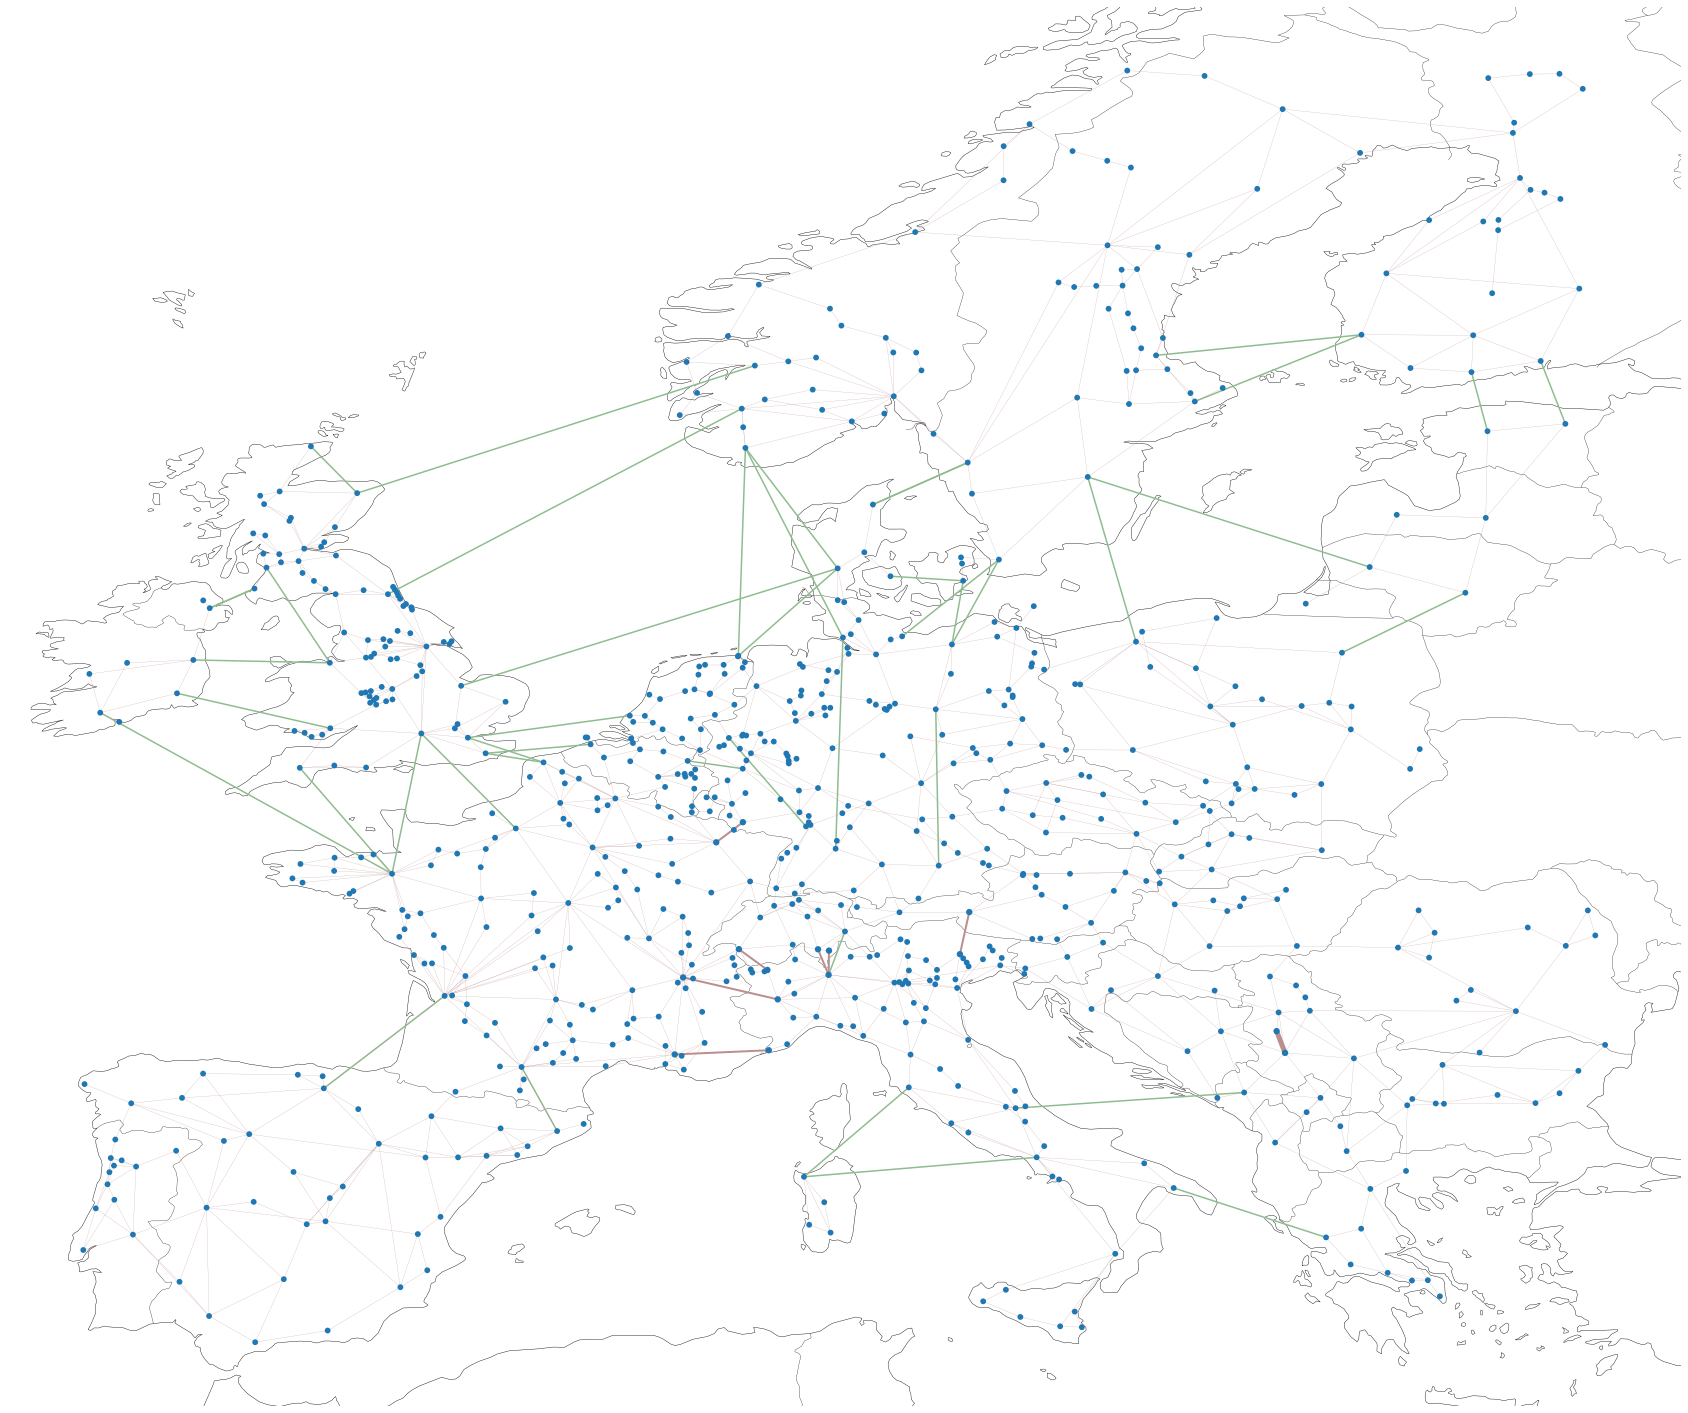

In [93]:
# Plot map of subgraphs and failing links

plt.figure(figsize=(30,30))
lws = np.ones(network.lines.shape[0])*0.2
bs = np.ones(network.buses.shape[0])*0.005
bc = np.ones(network.buses.shape[0])

failing_lines_names = utils.transform_cascade_results(G, cascade_results.secondary_failures_indices[result_idx])
for e in failing_lines_names:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=2
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
e = cascade_results.init_failure_name[result_idx]
lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=5
bs[network.buses.index==e[0]] =0.006
bs[network.buses.index==e[1]] =0.006
    

network.plot(line_widths=lws, bus_sizes=bs, jitter=0., bus_colors=bc, bus_cmap='tab20')